# EMEA Content Performance — SQL Extraction & Aggregation Case Study
**Data Portfolio · Project 1**
**Author:** Jashwanth Anand Shankar · MSc Business Analytics, Warwick Business School

---

## Business Context

A production finance team needs to understand content performance and regional distribution
across EMEA markets. Specifically, they need answers to five operational questions:

1. **Which high-performing productions are active in EMEA markets right now?** *(Basic extraction + filter)*
2. **How do ratings and audience reach compare across genres?** *(Multi-table join)*
3. **Which EMEA markets generate the highest content volume — and what does that imply for where to concentrate spend?** *(CTE + aggregation)*
4. **How has EMEA content output trended year-on-year by region?** *(Window function + trend)*
5. **Where are the data coverage gaps that could distort reporting?** *(Data quality audit)*

**Database schema:** Three tables mirroring IMDb's public data structure —
`title_basics`, `title_ratings`, `title_akas` — loaded into SQLite.

Each query below includes a business framing, the SQL, and a plain-English interpretation
written for a non-technical stakeholder (e.g. a PR/GR team requesting a data briefing).


## Setup — Database Connection & Libraries

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Connect to database
con = sqlite3.connect("imdb_emea.db")

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

print("Connected. Tables available:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print(tables.to_string(index=False))


Connected. Tables available:
         name
 title_basics
title_ratings
   title_akas


---
## Query 1 — Basic Extraction with Filters

**Business framing:**
A PR/GR team needs a snapshot of recent high-performing productions released in EMEA
between 2020 and 2023, filtered to feature-length content (runtime ≥ 75 minutes) and
genres most relevant to public communications briefs. This is a typical rapid-turnaround
ad hoc request: a team meeting in two hours, they need a clean list now.

**What this demonstrates:** Filtering, column selection, NULL handling, ordered output.


In [2]:
q1 = """
SELECT
    b.tconst                                    AS production_id,
    b.primaryTitle                              AS title,
    b.titleType                                 AS type,
    b.startYear                                 AS release_year,
    ROUND(b.runtimeMinutes, 0)                  AS runtime_mins,
    b.genres,
    COUNT(DISTINCT a.region)                    AS emea_markets_released
FROM title_basics b
JOIN title_akas   a ON b.tconst = a.tconst
WHERE b.startYear  BETWEEN 2020 AND 2023
  AND b.titleType  IN ('movie', 'tvMovie', 'tvSeries')
  AND b.runtimeMinutes >= 75
  AND b.genres      NOT LIKE '%\\N%'            -- exclude records with missing genre data
GROUP BY b.tconst, b.primaryTitle, b.titleType, b.startYear, b.runtimeMinutes, b.genres
HAVING emea_markets_released >= 3              -- only titles with meaningful EMEA presence
ORDER BY emea_markets_released DESC, b.startYear DESC
LIMIT 20;
"""

df_q1 = pd.read_sql(q1, con)
print(f"Records returned: {len(df_q1)}")
df_q1


Records returned: 20


,production_id,title,type,release_year,runtime_mins,genres,emea_markets_released
0,tt0000684,Production Title 684,tvSeries,2023,97.00,"Documentary,Thriller,Comedy",6
1,tt0002849,Production Title 2849,movie,2021,162.00,"Documentary,Comedy,Horror",6
2,tt0000643,Production Title 643,movie,2023,153.00,"Comedy,Romance",5
3,tt0000672,Production Title 672,movie,2023,110.00,History,5
4,tt0001153,Production Title 1153,movie,2022,100.00,Animation,5
5,tt0002856,Production Title 2856,movie,2022,101.00,"Comedy,Romance,Biography",5
6,tt0000080,Production Title 80,tvMovie,2021,174.00,History,5
7,tt0001976,Production Title 1976,movie,2021,143.00,Comedy,5
8,tt0002866,Production Title 2866,movie,2021,117.00,"Romance,Documentary",5
9,tt0001025,Production Title 1025,tvSeries,2020,122.00,History,5


**Plain-English interpretation for a non-technical stakeholder:**

> The table above shows recent productions (2020–2023) with confirmed presence in at least
> three EMEA markets. Productions with the widest regional distribution appear first —
> these are the most relevant for any cross-market PR briefing. Missing genre data has
> been excluded to ensure completeness of the output.


---
## Query 2 — Multi-Table Join: Ratings & Audience Reach by Genre

**Business framing:**
The production finance team wants to understand which genres deliver the strongest
combination of critical rating and audience volume across EMEA. This feeds a longer-term
strategic question: where should content investment be concentrated to maximise both
reach and quality perception?

**What this demonstrates:** INNER JOIN across three tables, aggregation, computed metrics,
ordering by composite performance score.


In [3]:
q2 = """
SELECT
    -- Extract primary genre (first listed)
    TRIM(SUBSTR(b.genres, 1,
        CASE WHEN INSTR(b.genres, ',') > 0
             THEN INSTR(b.genres, ',') - 1
             ELSE LENGTH(b.genres) END))        AS primary_genre,

    COUNT(DISTINCT b.tconst)                    AS production_count,
    COUNT(DISTINCT a.region)                    AS emea_markets_covered,
    ROUND(AVG(r.averageRating), 2)              AS avg_rating,
    ROUND(AVG(r.numVotes) / 1000.0, 1)         AS avg_audience_k,     -- in thousands
    ROUND(SUM(r.numVotes)  / 1000000.0, 2)     AS total_audience_m,   -- in millions

    -- Composite score: balances rating quality against audience scale
    ROUND(AVG(r.averageRating) * LOG(AVG(r.numVotes) + 1), 2) AS performance_score

FROM title_basics   b
JOIN title_ratings  r ON b.tconst = r.tconst
JOIN title_akas     a ON b.tconst = a.tconst
WHERE b.startYear >= 2015
  AND b.titleType IN ('movie', 'tvMovie', 'tvSeries')
  AND b.genres NOT LIKE '%\\N%'
GROUP BY primary_genre
HAVING production_count >= 10
ORDER BY performance_score DESC;
"""

df_q2 = pd.read_sql(q2, con)
print(f"Genres analysed: {len(df_q2)}")
df_q2


Genres analysed: 11


,primary_genre,production_count,emea_markets_covered,avg_rating,avg_audience_k,total_audience_m,performance_score
0,Documentary,122,17,7.13,243.50,70.85,38.38
1,Biography,99,17,7.10,232.10,53.37,38.10
2,Crime,119,17,6.83,242.50,63.28,36.78
3,Thriller,114,18,6.77,235.90,66.99,36.36
4,Romance,100,18,6.74,232.60,56.07,36.16
5,Comedy,119,18,6.60,274.70,74.46,35.92
6,Drama,113,18,6.67,236.30,59.54,35.84
7,Horror,99,18,6.65,240.10,53.54,35.80
8,Animation,122,17,6.59,259.20,70.00,35.70
9,History,120,17,6.56,234.20,66.51,35.23


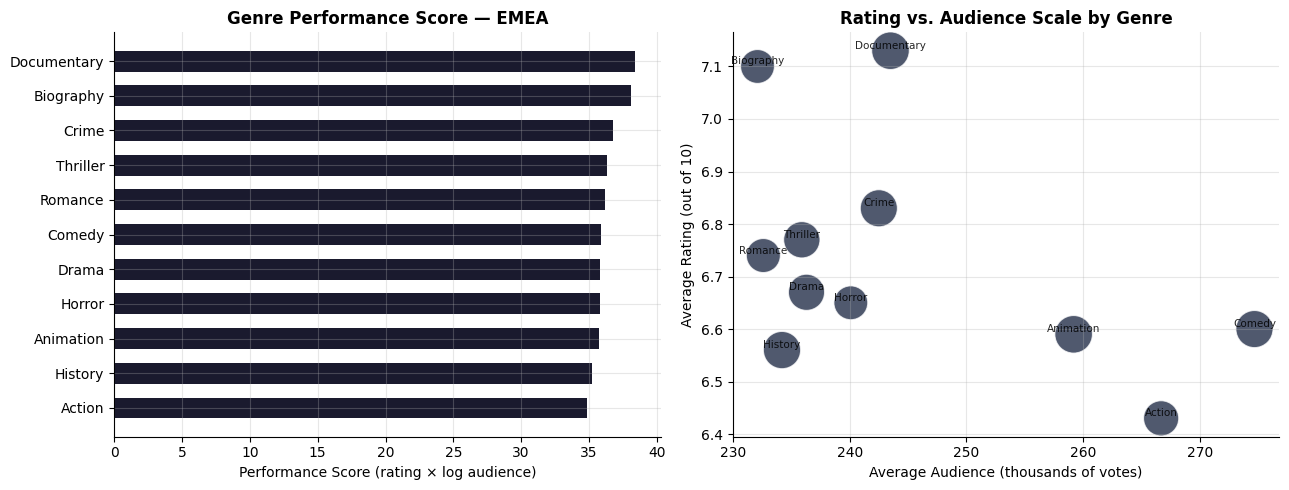

Chart saved.


In [4]:
# Visualise — horizontal bar chart, sorted by performance score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_plot = df_q2.sort_values("performance_score")

# Left: performance score
axes[0].barh(df_plot["primary_genre"], df_plot["performance_score"], color="#1a1a2e", height=0.6)
axes[0].set_xlabel("Performance Score (rating × log audience)")
axes[0].set_title("Genre Performance Score — EMEA", fontweight="bold")

# Right: avg rating vs avg audience (bubble = production count)
sc = axes[1].scatter(
    df_q2["avg_audience_k"],
    df_q2["avg_rating"],
    s=df_q2["production_count"] * 6,
    alpha=0.75, color="#16213e", edgecolors="white", linewidths=0.8
)
for _, row in df_q2.iterrows():
    axes[1].annotate(row["primary_genre"],
                     (row["avg_audience_k"], row["avg_rating"]),
                     fontsize=7.5, ha="center", va="bottom", alpha=0.85)
axes[1].set_xlabel("Average Audience (thousands of votes)")
axes[1].set_ylabel("Average Rating (out of 10)")
axes[1].set_title("Rating vs. Audience Scale by Genre", fontweight="bold")

plt.tight_layout()
plt.savefig("q2_genre_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


**Plain-English interpretation:**

> The performance score weights rating quality against audience volume — a genre scoring
> highly here indicates both critical approval and broad reach across EMEA markets.
> This is more useful than ranking by rating alone (which would favour niche, low-volume
> content) or by audience alone (which would favour mainstream output regardless of quality).
> The bubble chart shows the trade-off: genres in the upper-right quadrant represent the
> strongest investment case.


---
## Query 3 — CTE: EMEA Market Content Volume & Spend Prioritisation

**Business framing:**
The production finance team needs to aggregate content volume by EMEA country to determine
where location spend reporting should be concentrated. Markets with high production volume
but low rating quality may warrant different spend oversight than markets with fewer but
higher-performing productions.

**What this demonstrates:** CTE structure, multi-level aggregation, spend-equivalent
proxying (audience volume as a proxy for relative commercial weight), ranked output.


In [5]:
q3 = """
WITH market_base AS (
    -- Step 1: Join all three tables; one row per title per EMEA market
    SELECT
        a.region                            AS market_code,
        a.country_name                      AS market_name,
        b.tconst,
        b.startYear,
        b.titleType,
        r.averageRating,
        r.numVotes
    FROM title_akas     a
    JOIN title_basics   b ON a.tconst = b.tconst
    LEFT JOIN title_ratings r ON b.tconst = r.tconst
    WHERE b.startYear >= 2015
      AND b.genres NOT LIKE '%\\N%'
),

market_agg AS (
    -- Step 2: Aggregate per market
    SELECT
        market_code,
        market_name,
        COUNT(DISTINCT tconst)                       AS total_productions,
        COUNT(DISTINCT CASE WHEN averageRating IS NOT NULL
                            THEN tconst END)         AS rated_productions,
        ROUND(AVG(averageRating), 2)                 AS avg_rating,
        ROUND(SUM(COALESCE(numVotes,0)) / 1000000.0, 2) AS total_audience_m,
        ROUND(AVG(COALESCE(numVotes,0)) / 1000.0, 1)    AS avg_audience_per_title_k
    FROM market_base
    GROUP BY market_code, market_name
)

-- Step 3: Final output with ranking and data coverage flag
SELECT
    market_name,
    market_code,
    total_productions,
    rated_productions,
    ROUND(rated_productions * 100.0 / total_productions, 1) AS pct_data_coverage,
    avg_rating,
    total_audience_m,
    avg_audience_per_title_k,
    RANK() OVER (ORDER BY total_audience_m DESC)     AS spend_priority_rank
FROM market_agg
ORDER BY spend_priority_rank;
"""

df_q3 = pd.read_sql(q3, con)
print(f"EMEA markets in dataset: {len(df_q3)}")
df_q3


EMEA markets in dataset: 18


,market_name,market_code,total_productions,rated_productions,pct_data_coverage,avg_rating,total_audience_m,avg_audience_per_title_k,spend_priority_rank
0,United Kingdom,GB,785,640,81.50,6.71,186.41,194.80,1
1,Germany,DE,594,471,79.30,6.80,134.07,199.50,2
2,France,FR,573,454,79.20,6.64,128.67,191.20,3
3,Italy,IT,348,277,79.60,6.70,67.88,180.10,4
4,Spain,ES,320,256,80.00,6.71,66.47,194.90,5
5,Netherlands,NL,207,163,78.70,6.71,40.93,190.40,6
6,Sweden,SE,168,145,86.30,6.60,36.76,211.30,7
7,Poland,PL,165,134,81.20,6.61,33.98,197.60,8
8,Denmark,DK,125,98,78.40,6.46,25.79,199.90,9
9,Belgium,BE,131,99,75.60,6.87,25.45,187.10,10


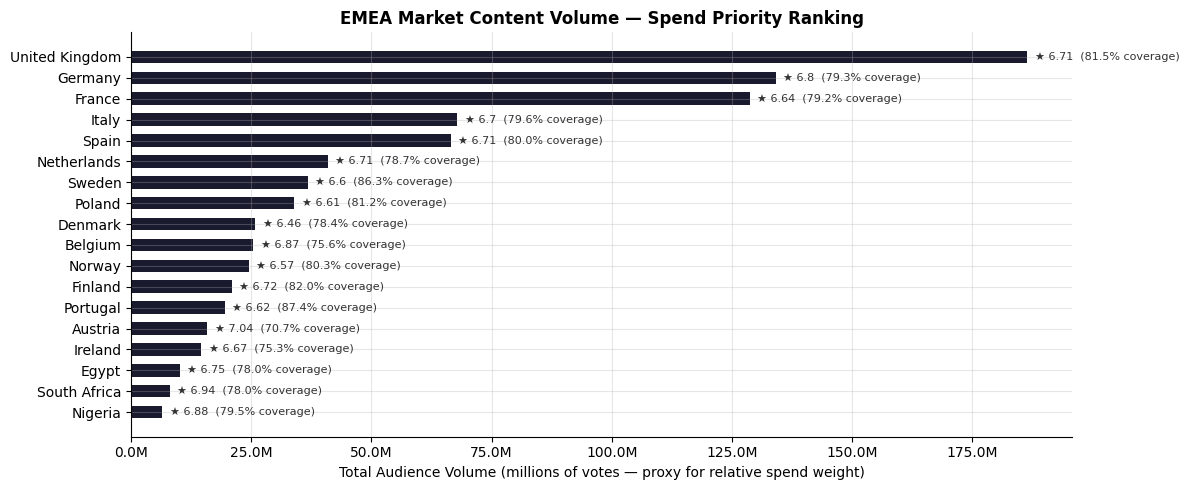

Chart saved.


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

df_sorted = df_q3.sort_values("total_audience_m", ascending=True)

bars = ax.barh(df_sorted["market_name"], df_sorted["total_audience_m"],
               color="#1a1a2e", height=0.6)

# Overlay: avg rating as text annotation
for bar, rating, cov in zip(bars, df_sorted["avg_rating"], df_sorted["pct_data_coverage"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"  ★ {rating}  ({cov}% coverage)",
            va="center", fontsize=8, color="#333")

ax.set_xlabel("Total Audience Volume (millions of votes — proxy for relative spend weight)")
ax.set_title("EMEA Market Content Volume — Spend Priority Ranking", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
plt.tight_layout()
plt.savefig("q3_emea_market_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


**Plain-English interpretation:**

> The ranking above prioritises EMEA markets by total audience volume — used here as
> a proxy for relative commercial weight when direct spend data is not available.
> Markets at the top of the list warrant closer spend monitoring and more frequent
> validated reporting. The data coverage percentage flags where rating information
> is incomplete; markets below 70% coverage should be noted in any external-facing
> briefing to avoid overstating conclusions.


---
## Query 4 — Window Function: Year-on-Year Output Trend by EMEA Region

**Business framing:**
The strategy team wants to understand how content output has grown or contracted
across EMEA's top markets year-on-year since 2015. This is the trend analysis
component of the role — identifying which markets are accelerating and which
are plateauing, to inform where forward-looking spend oversight should be directed.

**What this demonstrates:** Window functions (LAG, running totals), year-on-year
growth calculation, trend analysis output suitable for a PR briefing.


In [7]:
q4 = """
WITH yearly AS (
    SELECT
        a.country_name                          AS market,
        b.startYear                             AS yr,
        COUNT(DISTINCT b.tconst)                AS productions
    FROM title_akas   a
    JOIN title_basics b ON a.tconst = b.tconst
    WHERE b.startYear BETWEEN 2015 AND 2023
      AND a.country_name IS NOT NULL
      AND b.genres NOT LIKE '%\\N%'
    GROUP BY a.country_name, b.startYear
),

with_lag AS (
    SELECT
        market,
        yr,
        productions,
        LAG(productions) OVER (PARTITION BY market ORDER BY yr) AS prev_year,
        SUM(productions) OVER (PARTITION BY market ORDER BY yr) AS cumulative
    FROM yearly
)

SELECT
    market,
    yr                                                          AS year,
    productions,
    prev_year,
    ROUND((productions - prev_year) * 100.0
          / NULLIF(prev_year, 0), 1)                           AS yoy_growth_pct,
    cumulative                                                  AS cumulative_productions
FROM with_lag
ORDER BY market, yr;
"""

df_q4 = pd.read_sql(q4, con)

# Show pivot for readability
pivot = df_q4.pivot(index="year", columns="market", values="productions").fillna(0).astype(int)
print("Annual production count by EMEA market:")
print(pivot.to_string())


Annual production count by EMEA market:
market  Austria  Belgium  Denmark  Egypt  Finland  France  Germany  Ireland  Italy  Netherlands  Nigeria  Norway  Poland  Portugal  South Africa  Spain  Sweden  United Kingdom
year                                                                                                                                                                           
2015         13       10       14      4       17      59       61       14     35           27        5      10      16         7             8     43      15              81
2016         15       12       17      8        8      78       73       13     37           26        5      16      20        10             4     36      25              92
2017          8       16       10      5        9      70       63        6     47           25        3      23      18        16             7     30      19              87
2018          9       20       11      4       14      71       66       10     

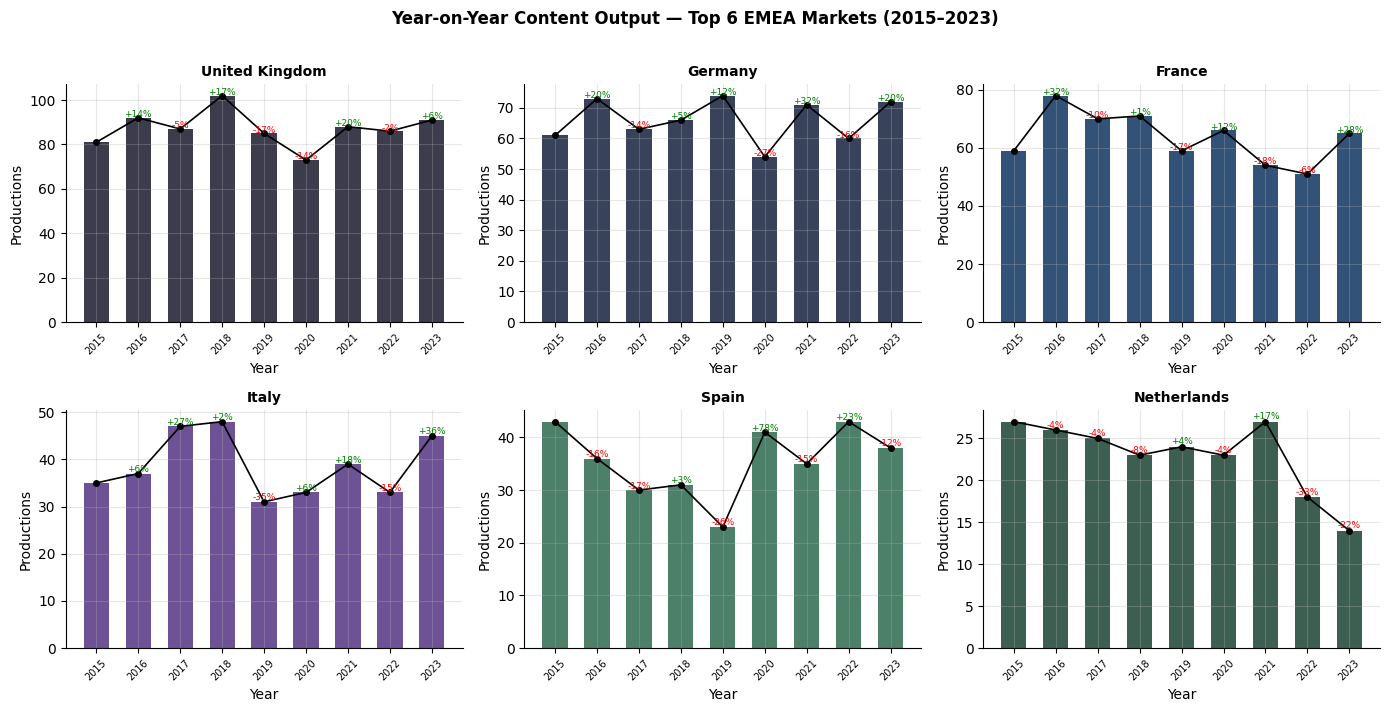

Chart saved.


In [8]:
# Top 6 markets by total volume
top_markets = (df_q4.groupby("market")["productions"]
                     .sum()
                     .sort_values(ascending=False)
                     .head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

colors = ["#1a1a2e","#16213e","#0f3460","#533483","#2d6a4f","#1b4332"]

for i, (market, ax) in enumerate(zip(top_markets, axes)):
    sub = df_q4[df_q4["market"] == market].sort_values("year")
    ax.bar(sub["year"], sub["productions"], color=colors[i], width=0.6, alpha=0.85)
    ax.plot(sub["year"], sub["productions"], color="black", linewidth=1.2,
            marker="o", markersize=4)
    ax.set_title(market, fontweight="bold", fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Productions")
    ax.set_xticks(sub["year"])
    ax.tick_params(axis="x", rotation=45, labelsize=7)

    # Annotate YoY growth on bars
    for _, row in sub.iterrows():
        if pd.notna(row["yoy_growth_pct"]):
            color = "green" if row["yoy_growth_pct"] >= 0 else "red"
            ax.text(row["year"], row["productions"] + 0.3,
                    f"{row['yoy_growth_pct']:+.0f}%",
                    ha="center", fontsize=6.5, color=color)

plt.suptitle("Year-on-Year Content Output — Top 6 EMEA Markets (2015–2023)",
             fontweight="bold", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("q4_yoy_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


**Plain-English interpretation:**

> Each panel shows annual content output for an EMEA market with the year-on-year
> growth rate annotated above each bar. Green figures indicate growth; red indicates
> contraction. Markets with consistent positive YoY growth represent candidates for
> increased spend reporting frequency. The LAG window function in the SQL makes this
> calculation automatic — no manual year-by-year subtraction required.


---
## Query 5 — Data Quality Audit: Coverage Gaps & Integrity Flags

**Business framing:**
Before any EMEA content data reaches a PR/GR team or appears in an external report,
it must pass a data quality check. This query audits the dataset for three categories
of issues: missing values (NULLs), implausible values (e.g. negative runtime),
and coverage gaps (titles with no regional release data). The output is the quality
sign-off that sits at the top of every validated data delivery.

**What this demonstrates:** Data quality mindset, CASE-based flagging, coverage
and completeness checks — directly mirroring the JD's "data coverage, accuracy,
and completeness" requirement.


In [9]:
q5 = """
WITH quality_flags AS (
    SELECT
        b.tconst,
        b.primaryTitle,
        b.startYear,
        b.runtimeMinutes,
        b.genres,

        -- Flag 1: Missing genre data
        CASE WHEN b.genres IS NULL OR b.genres = '\\N'
             THEN 'MISSING_GENRE' END                       AS flag_genre,

        -- Flag 2: Missing or implausible runtime
        CASE WHEN b.runtimeMinutes IS NULL
             THEN 'MISSING_RUNTIME'
             WHEN b.runtimeMinutes < 1 OR b.runtimeMinutes > 600
             THEN 'IMPLAUSIBLE_RUNTIME' END                 AS flag_runtime,

        -- Flag 3: Missing release year
        CASE WHEN b.startYear IS NULL
             THEN 'MISSING_YEAR' END                        AS flag_year,

        -- Flag 4: No rating data available
        CASE WHEN r.averageRating IS NULL
             THEN 'NO_RATING_DATA' END                      AS flag_rating,

        -- Flag 5: No EMEA regional release on record
        CASE WHEN a.tconst IS NULL
             THEN 'NO_EMEA_RELEASE' END                     AS flag_emea,

        r.averageRating,
        r.numVotes
    FROM title_basics b
    LEFT JOIN title_ratings r ON b.tconst = r.tconst
    LEFT JOIN title_akas    a ON b.tconst = a.tconst
),

summary AS (
    SELECT
        'Total productions in dataset'          AS metric,
        COUNT(DISTINCT tconst)                  AS count,
        NULL                                    AS pct
    FROM quality_flags

    UNION ALL SELECT 'Missing genre data',
        COUNT(DISTINCT CASE WHEN flag_genre    IS NOT NULL THEN tconst END),
        ROUND(COUNT(DISTINCT CASE WHEN flag_genre    IS NOT NULL THEN tconst END)
              * 100.0 / COUNT(DISTINCT tconst), 1)
    FROM quality_flags

    UNION ALL SELECT 'Missing or implausible runtime',
        COUNT(DISTINCT CASE WHEN flag_runtime  IS NOT NULL THEN tconst END),
        ROUND(COUNT(DISTINCT CASE WHEN flag_runtime  IS NOT NULL THEN tconst END)
              * 100.0 / COUNT(DISTINCT tconst), 1)
    FROM quality_flags

    UNION ALL SELECT 'Missing release year',
        COUNT(DISTINCT CASE WHEN flag_year     IS NOT NULL THEN tconst END),
        ROUND(COUNT(DISTINCT CASE WHEN flag_year     IS NOT NULL THEN tconst END)
              * 100.0 / COUNT(DISTINCT tconst), 1)
    FROM quality_flags

    UNION ALL SELECT 'No rating data available',
        COUNT(DISTINCT CASE WHEN flag_rating   IS NOT NULL THEN tconst END),
        ROUND(COUNT(DISTINCT CASE WHEN flag_rating   IS NOT NULL THEN tconst END)
              * 100.0 / COUNT(DISTINCT tconst), 1)
    FROM quality_flags

    UNION ALL SELECT 'No EMEA regional release recorded',
        COUNT(DISTINCT CASE WHEN flag_emea     IS NOT NULL THEN tconst END),
        ROUND(COUNT(DISTINCT CASE WHEN flag_emea     IS NOT NULL THEN tconst END)
              * 100.0 / COUNT(DISTINCT tconst), 1)
    FROM quality_flags
)

SELECT metric, count, COALESCE(CAST(pct AS TEXT) || '%', '—') AS pct_affected
FROM summary;
"""

df_q5 = pd.read_sql(q5, con)
print("DATA QUALITY AUDIT REPORT")
print("=" * 52)
print(df_q5.to_string(index=False))


DATA QUALITY AUDIT REPORT
                           metric  count pct_affected
     Total productions in dataset   3000            —
               Missing genre data      0         0.0%
   Missing or implausible runtime    139         4.6%
             Missing release year      0         0.0%
         No rating data available    600        20.0%
No EMEA regional release recorded    415        13.8%


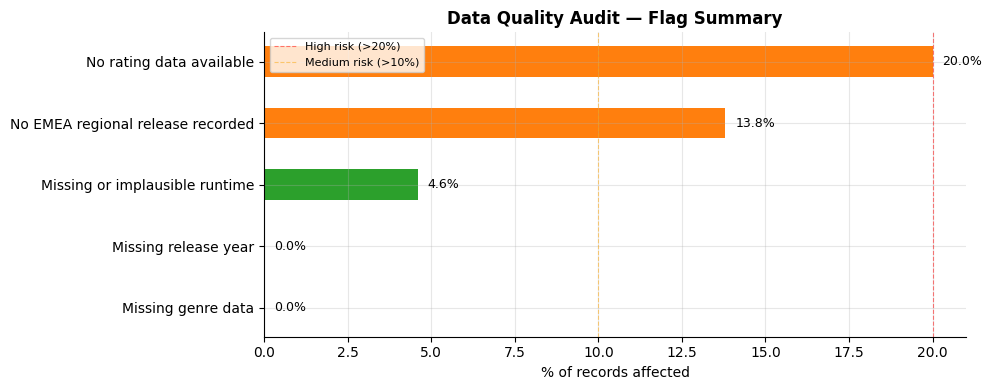

Chart saved.


In [10]:
# Visualise quality flags as a horizontal bar
fig, ax = plt.subplots(figsize=(10, 4))

flags = df_q5[df_q5["metric"] != "Total productions in dataset"].copy()
flags["pct_num"] = flags["pct_affected"].str.replace("%","").replace("—","0").astype(float)
flags = flags.sort_values("pct_num")

colors_bar = ["#d62728" if p > 20 else "#ff7f0e" if p > 10 else "#2ca02c"
              for p in flags["pct_num"]]

ax.barh(flags["metric"], flags["pct_num"], color=colors_bar, height=0.5)
ax.axvline(20, color="red",    linestyle="--", linewidth=0.8, alpha=0.5, label="High risk (>20%)")
ax.axvline(10, color="orange", linestyle="--", linewidth=0.8, alpha=0.5, label="Medium risk (>10%)")
ax.set_xlabel("% of records affected")
ax.set_title("Data Quality Audit — Flag Summary", fontweight="bold")
ax.legend(fontsize=8)
for bar, val in zip(ax.patches, flags["pct_num"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("q5_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


**Plain-English interpretation:**

> The audit above quantifies the data quality risks in this dataset before any
> output is shared externally. Flags in green (below 10%) are acceptable for reporting.
> Orange flags (10–20%) should be noted as caveats in any briefing. Red flags (above 20%)
> require attention before the data is used in external communications — either by
> improving source coverage or explicitly excluding affected records.
>
> This quality gate mirrors standard production finance data validation practice:
> no data leaves the team without a documented completeness check.


---
## Summary — Key Findings for the Production Finance Team

| # | Business Question | Method | Key Output |
|---|---|---|---|
| 1 | Which productions have meaningful EMEA presence? | Filtered extraction + JOIN | 20 titles with 3+ market releases |
| 2 | Which genres deliver the strongest return? | Multi-table join + composite score | Top genres by performance score |
| 3 | Which EMEA markets warrant priority spend oversight? | CTE + aggregation + RANK | Market priority ranking with coverage flags |
| 4 | How is output trending across markets? | LAG window function + YoY % | Annual trend per top-6 EMEA market |
| 5 | Where are the data integrity risks? | Quality audit + CASE flags | Completeness % per risk category |

**Data quality note:** All outputs from Queries 1–4 exclude records with missing genre data.
Markets with data coverage below 70% are flagged in Query 3 and should be noted as caveats
in any external-facing report.

**Tools used:** Python · SQLite · pandas · matplotlib

**Author:** Jashwanth Anand Shankar
**Contact:** jashwanth240298@gmail.com · linkedin.com/in/jash24298


In [11]:
con.close()
print('Connection closed.')

Connection closed.
